In [1]:
import pandas as pd

df = pd.read_csv('D:\\Projects\\Future Interns\\Task 3\\data\\bank-additional-full.csv', sep=';')

df.head()

df.info()

df.describe()



<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [2]:
# Check for "unknown" values hiding in categorical columns
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(col, ':', df[col].unique())
    

job : <StringArray>
[    'housemaid',      'services',        'admin.',   'blue-collar',
    'technician',       'retired',    'management',    'unemployed',
 'self-employed',       'unknown',  'entrepreneur',       'student']
Length: 12, dtype: str
marital : <StringArray>
['married', 'single', 'divorced', 'unknown']
Length: 4, dtype: str
education : <StringArray>
[           'basic.4y',         'high.school',            'basic.6y',
            'basic.9y', 'professional.course',             'unknown',
   'university.degree',          'illiterate']
Length: 8, dtype: str
default : <StringArray>
['no', 'unknown', 'yes']
Length: 3, dtype: str
housing : <StringArray>
['no', 'yes', 'unknown']
Length: 3, dtype: str
loan : <StringArray>
['no', 'yes', 'unknown']
Length: 3, dtype: str
contact : <StringArray>
['telephone', 'cellular']
Length: 2, dtype: str
month : <StringArray>
['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr', 'sep']
Length: 10, dtype: str
day_of_week : <StringArray

C:\Users\user\AppData\Local\Temp\ipykernel_28756\4139320272.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [3]:
categorical_cols = df.select_dtypes(include='str').columns

In [4]:
# Turn the 999 placeholder into something meaningful
df['was_contacted_before'] = df['pdays'] != 999

In [6]:
unknown_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan']

df_clean = df[~(df[unknown_cols] == 'unknown').any(axis=1)]

print(f"Original rows: {len(df)}")
print(f"After dropping unknowns: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")

Original rows: 41188
After dropping unknowns: 30488
Rows removed: 10700


In [7]:
median_duration = df_clean['duration'].median()
print(f"Median call duration: {median_duration} seconds")

# Stage flags
df_clean['stage_1_contacted'] = True  # everyone starts here
df_clean['stage_2_engaged'] = df_clean['duration'] >= median_duration
df_clean['stage_3_converted'] = df_clean['y'] == 'yes'

Median call duration: 181.0 seconds


In [8]:
stage_1 = df_clean['stage_1_contacted'].sum()
stage_2 = df_clean['stage_2_engaged'].sum()
stage_3 = df_clean['stage_3_converted'].sum()

print(f"Stage 1 - Contacted: {stage_1}")
print(f"Stage 2 - Engaged:   {stage_2}  ({stage_2/stage_1*100:.1f}% of Stage 1)")
print(f"Stage 3 - Converted: {stage_3}  ({stage_3/stage_2*100:.1f}% of Stage 2)")
print(f"Overall conversion:  {stage_3/stage_1*100:.1f}% (Stage 3 of Stage 1)")

Stage 1 - Contacted: 30488
Stage 2 - Engaged:   15245  (50.0% of Stage 1)
Stage 3 - Converted: 3859  (25.3% of Stage 2)
Overall conversion:  12.7% (Stage 3 of Stage 1)


In [9]:
# Make stage_3 a true subset of stage_2
df_clean['stage_3_converted'] = df_clean['stage_2_engaged'] & (df_clean['y'] == 'yes')

stage_1 = df_clean['stage_1_contacted'].sum()
stage_2 = df_clean['stage_2_engaged'].sum()
stage_3 = df_clean['stage_3_converted'].sum()

print(f"Stage 1 - Contacted: {stage_1}")
print(f"Stage 2 - Engaged:   {stage_2}  ({stage_2/stage_1*100:.1f}% of Stage 1)")
print(f"Stage 3 - Converted: {stage_3}  ({stage_3/stage_2*100:.1f}% of Stage 2)")
print(f"Overall conversion:  {stage_3/stage_1*100:.1f}% (Stage 3 of Stage 1)")

Stage 1 - Contacted: 30488
Stage 2 - Engaged:   15245  (50.0% of Stage 1)
Stage 3 - Converted: 3361  (22.0% of Stage 2)
Overall conversion:  11.0% (Stage 3 of Stage 1)


In [10]:
channel_funnel = df_clean.groupby('contact').agg(
    contacted=('stage_1_contacted', 'sum'),
    engaged=('stage_2_engaged', 'sum'),
    converted=('stage_3_converted', 'sum')
)

channel_funnel['engage_rate_%'] = (channel_funnel['engaged'] / channel_funnel['contacted'] * 100).round(1)
channel_funnel['convert_rate_%'] = (channel_funnel['converted'] / channel_funnel['engaged'] * 100).round(1)
channel_funnel['overall_rate_%'] = (channel_funnel['converted'] / channel_funnel['contacted'] * 100).round(1)

channel_funnel

,contacted,engaged,converted,engage_rate_%,convert_rate_%,overall_rate_%
contact,,,,,,
cellular,20443,10370,2829,50.7,27.3,13.8
telephone,10045,4875,532,48.5,10.9,5.3


In [11]:
month_funnel = df_clean.groupby('month').agg(
    contacted=('stage_1_contacted', 'sum'),
    engaged=('stage_2_engaged', 'sum'),
    converted=('stage_3_converted', 'sum')
)

month_funnel['overall_rate_%'] = (month_funnel['converted'] / month_funnel['contacted'] * 100).round(1)

# Sort by calendar order instead of alphabetical
month_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_funnel = month_funnel.reindex(month_order)

month_funnel

,contacted,engaged,converted,overall_rate_%
month,,,,
mar,482,252,181,37.6
apr,2115,1233,383,18.1
may,9733,5137,676,6.9
jun,3614,1712,386,10.7
jul,5081,2606,489,9.6
aug,4673,1970,467,10.0
sep,495,300,188,38.0
oct,642,357,219,34.1
nov,3496,1569,306,8.8


In [12]:
import os
os.makedirs('charts', exist_ok=True)

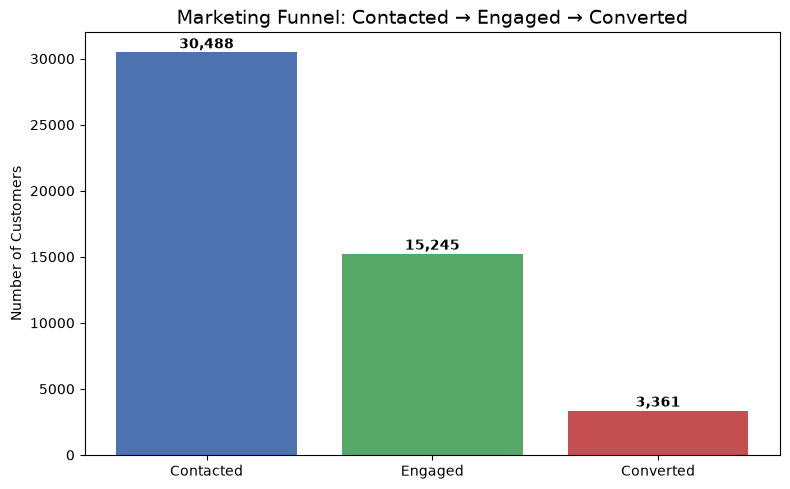

In [13]:
import matplotlib.pyplot as plt

stages = ['Contacted', 'Engaged', 'Converted']
values = [stage_1, stage_2, stage_3]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(stages, values, color=['#4C72B0', '#55A868', '#C44E52'])

# Add value labels on top of each bar
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, value + 300, f'{value:,}', 
            ha='center', fontweight='bold')

ax.set_title('Marketing Funnel: Contacted → Engaged → Converted', fontsize=14)
ax.set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig('charts/funnel_overview.png', dpi=150)
plt.show()

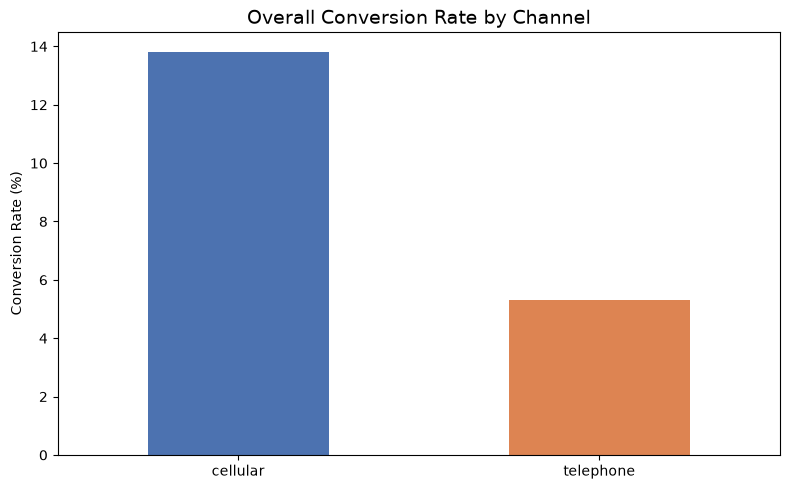

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
channel_funnel['overall_rate_%'].plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])

ax.set_title('Overall Conversion Rate by Channel', fontsize=14)
ax.set_ylabel('Conversion Rate (%)')
ax.set_xlabel('')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('charts/channel_comparison.png', dpi=150)
plt.show()

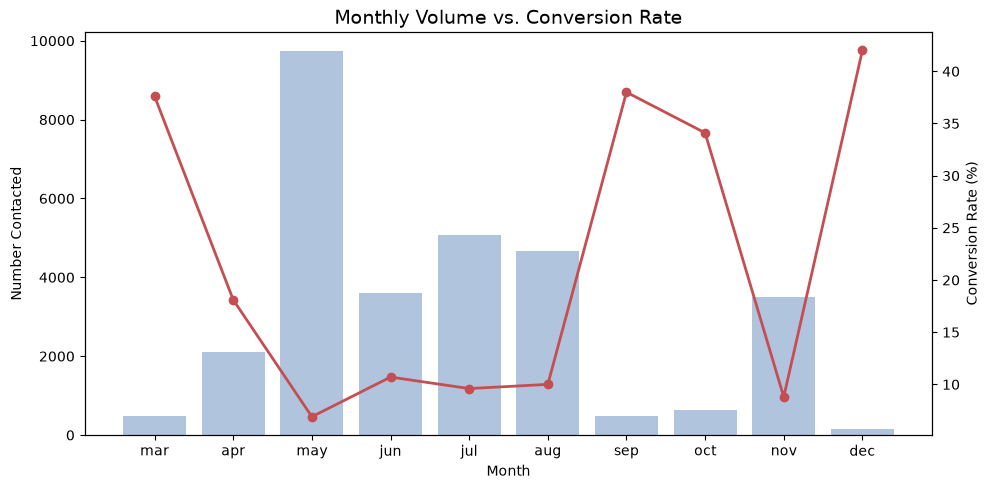

In [15]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(month_funnel.index, month_funnel['contacted'], color='#B0C4DE', label='Contacted (volume)')
ax1.set_ylabel('Number Contacted')
ax1.set_xlabel('Month')

ax2 = ax1.twinx()  # creates a second y-axis sharing the same x-axis
ax2.plot(month_funnel.index, month_funnel['overall_rate_%'], color='#C44E52', 
          marker='o', linewidth=2, label='Conversion Rate')
ax2.set_ylabel('Conversion Rate (%)')

ax1.set_title('Monthly Volume vs. Conversion Rate', fontsize=14)
fig.tight_layout()
plt.savefig('charts/monthly_trend.png', dpi=150)
plt.show()

In [16]:
import plotly.graph_objects as go

fig = go.Figure(go.Funnel(
    y=['Contacted', 'Engaged', 'Converted'],
    x=[stage_1, stage_2, stage_3],
    textinfo='value+percent initial',
    marker={'color': ['#4C72B0', '#55A868', '#C44E52']}
))

fig.update_layout(title='Marketing Funnel: Drop-off by Stage', title_x=0.5)

fig.write_image('charts/funnel_diagram.png', scale=2)
fig.show()

In [18]:
df_clean.to_csv('D:/Projects/Future Interns/Task 3/data/bank_clean.csv', index=False)